In [8]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset
import math
import scipy.special
import random as rd
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


### Loading cifar-10 dataset

In [2]:
# Define transforms for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]) # imageNet stats by rgb channel

# Load full training set (50,000 samples)
full_train_dataset = datasets.CIFAR10(root="C:/Users/ejeme/Documents/python_repos/CIFAR/cifar_data", train=True, transform=transform, download=True)
# Load official test set (10,000 samples)
official_test_dataset = datasets.CIFAR10(root="C:/Users/ejeme/Documents/python_repos/CIFAR/cifar_data", train=False, transform=transform, download=True)

# Keep only classes 0 (airplane) and 1 (automobile)
filtered_train_dataset = filter_classes(full_train_dataset, [0, 1])
filtered_test_dataset = filter_classes(official_test_dataset, [0, 1])

In [4]:
len(filtered_train_dataset)

10000

In [5]:
len(filtered_test_dataset)

2000

In [6]:
train_size = 5000
extra_test_size = len(filtered_train_dataset) - train_size
# Use a fixed seed for reproducibility
generator = torch.Generator().manual_seed(42)
train_dataset, extra_test_dataset = random_split(filtered_train_dataset, [train_size, extra_test_size], generator=generator)
# Concatenate the 20k extra test samples with the official test set
combined_test_dataset = ConcatDataset([extra_test_dataset, filtered_test_dataset])
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
test_loader = DataLoader(combined_test_dataset, batch_size=6, shuffle=False)

## Training small CNN for cifar-2 classification task

In [7]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet-18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Replace the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # For binary classification

# Move model to the device
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ejeme/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 54.6MB/s]


In [9]:
# Define Loss, Optimizer and lr scheduler
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=0)

# Training Loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    print('TRAINING EPOCH', epoch)
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
    print(f"Train Accuracy: {100 * correct / total:.2f}%")

    # Evaluate model at the end of current epoch
    model.eval()
    correct = 0
    total = 0
    print('TESTING')
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f"Validation Accuracy: {100 * correct / total:.2f}%")
    scheduler.step(correct)

    torch.save(model.state_dict(), "C:/Users/ejeme/Documents/python_repos/CIFAR/resnet18_cifar_binary_epoch"+str(epoch)+".pth")

TRAINING EPOCH 0


100%|██████████| 834/834 [00:18<00:00, 44.45it/s]


Epoch [1/20], Loss: 0.1811
Train Accuracy: 93.38%
TESTING
Validation Accuracy: 98.20%
TRAINING EPOCH 1


100%|██████████| 834/834 [00:16<00:00, 49.39it/s]


Epoch [2/20], Loss: 0.0904
Train Accuracy: 97.16%
TESTING
Validation Accuracy: 98.77%
TRAINING EPOCH 2


...

Epoch [18/20], Loss: 0.0053
Train Accuracy: 99.94%
TESTING
Validation Accuracy: 99.20%
TRAINING EPOCH 18


100%|██████████| 834/834 [00:16<00:00, 49.25it/s]


Epoch [19/20], Loss: 0.0051
Train Accuracy: 99.96%
TESTING
Validation Accuracy: 99.14%
TRAINING EPOCH 19


100%|██████████| 834/834 [00:16<00:00, 49.50it/s]


Epoch [20/20], Loss: 0.0054
Train Accuracy: 99.98%
TESTING
Validation Accuracy: 99.11%


### Retrieving Softmax Response, Predicted class and True class for all samples in resnet18 test set 

In [13]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet-18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
# Replace the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # For binary classification

checkpoint = torch.load("C:/Users/ejeme/Documents/python_repos/CIFAR/resnet18_cifar_binary_epoch19.pth")
model.load_state_dict(checkpoint)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
sgr_dico = prepare_sgr_dico(test_loader, model = model, device = device, T = 1)
sgr_set = pd.DataFrame(sgr_dico)
pickle.dump(sgr_set, open('sgr_set_resnet','wb'))

100%|██████████| 1167/1167 [00:10<00:00, 115.41it/s]


In [15]:
sgr_set.sort_values('SR')

,y_true,y_pred,SR
1502,1.0,1.0,0.504141
5161,0.0,1.0,0.504888
3226,0.0,0.0,0.510480
4757,1.0,0.0,0.518604
4148,1.0,1.0,0.520101
...,...,...,...
6237,1.0,1.0,1.000000
4229,1.0,1.0,1.000000
6908,1.0,1.0,1.000000
627,0.0,0.0,1.000000


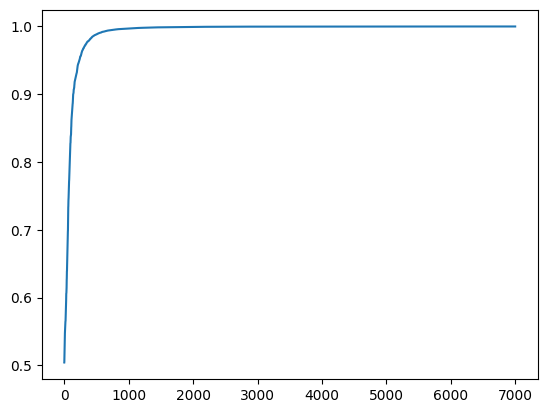

In [16]:
plt.plot(list(sgr_set.sort_values('SR').SR))
plt.show()